# ICU Alarm Fatigue — Data Cleaning
### Place this file at: `~/PycharmProjects/ECG_Fatigue/notebooks/`
All paths below are relative to that notebooks/ folder.

In [1]:
import wfdb
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── LOCAL PATHS (relative to notebooks/ folder) ──────────────────────────────
PATH_2015   = '../Data/physionet2015'   # .hea + .mat files + ALARMS
PATH_MITBIH = '../Data/mitbih'          # 100.csv, 100annotations.txt ...
PATH_MIMIC  = '../Data/MimicDemo'       # CHARTEVENTS.csv, PATIENTS.csv ...
PATH_RESULTS = '../results'
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(PATH_RESULTS, exist_ok=True)

# Verify all folders exist
for name, p in [('physionet2015', PATH_2015),
                ('mitbih',        PATH_MITBIH),
                ('MimicDemo',     PATH_MIMIC)]:
    exists = os.path.isdir(p)
    print(f"{'✅' if exists else '❌'}  {name:<15} → {os.path.abspath(p)}")

✅  physionet2015   → /Users/adityasitapara/PycharmProjects/ECG_Fatigue/Backend/Data/physionet2015
✅  mitbih          → /Users/adityasitapara/PycharmProjects/ECG_Fatigue/Backend/Data/mitbih
✅  MimicDemo       → /Users/adityasitapara/PycharmProjects/ECG_Fatigue/Backend/Data/MimicDemo


---
## SECTION 1 — PhysioNet 2015 Challenge Data

In [2]:
# ── Cell 1: Load records + ALARMS file ───────────────────────────────────────
records = [f.replace('.hea', '') for f in os.listdir(PATH_2015) if f.endswith('.hea')]
print(f"Total records found: {len(records)}")  # Expect 750

alarm_labels = {}
alarm_types  = {}

# ALARMS format in your data: record_id,alarm_type,label  (0=False, 1=True)
with open(f'{PATH_2015}/ALARMS', 'r') as f:
    for line in f:
        parts = line.strip().split(',')
        if len(parts) == 3:
            alarm_labels[parts[0]] = int(parts[2])
            alarm_types[parts[0]]  = parts[1]

print(f"Labels loaded: {len(alarm_labels)}")   # Expect 750
print(f"Sample → {list(alarm_labels.items())[:3]}")

Total records found: 750
Labels loaded: 750
Sample → [('v100s', 0), ('v101l', 0), ('v102s', 0)]


In [3]:
# ── Cell 2: Build master record dataframe ────────────────────────────────────
records_info = []

for rec_id in records:
    try:
        rec = wfdb.rdrecord(f'{PATH_2015}/{rec_id}')
        sig = rec.p_signal

        has_nan    = np.isnan(sig).any()
        nan_pct    = np.isnan(sig).mean() * 100
        n_channels = sig.shape[1]
        n_samples  = sig.shape[0]
        duration   = n_samples / rec.fs
        ecg_col    = 0

        records_info.append({
            'record_id'  : rec_id,
            'label'      : alarm_labels.get(rec_id, -1),
            'alarm_type' : alarm_types.get(rec_id, 'unknown'),
            'n_channels' : n_channels,
            'n_samples'  : n_samples,
            'duration_s' : duration,
            'fs'         : rec.fs,
            'has_nan'    : has_nan,
            'nan_pct'    : nan_pct,
            'sig_names'  : str(rec.sig_name),
            'ecg_min'    : np.nanmin(sig[:, ecg_col]),
            'ecg_max'    : np.nanmax(sig[:, ecg_col]),
            'ecg_std'    : np.nanstd(sig[:, ecg_col]),
        })
    except Exception as e:
        print(f"⚠️  Failed: {rec_id} — {e}")

df_records = pd.DataFrame(records_info)
print(df_records.shape)
df_records.head()

(750, 13)


,record_id,label,alarm_type,n_channels,n_samples,duration_s,fs,has_nan,nan_pct,sig_names,ecg_min,ecg_max,ecg_std
0,v845l,0,Ventricular_Tachycardia,4,82500,330.0,250,False,0.0,"['II', 'V', 'ABP', 'RESP']",-0.430736,1.560823,0.240712
1,b578s,1,Bradycardia,4,75000,300.0,250,False,0.0,"['II', 'V', 'ABP', 'RESP']",-0.128098,1.215070,0.080588
2,f493l,0,Ventricular_Flutter_Fib,4,82500,330.0,250,False,0.0,"['II', 'V', 'ABP', 'RESP']",-0.605765,1.527273,0.538887
3,v453l,0,Ventricular_Tachycardia,3,82500,330.0,250,False,0.0,"['II', 'V', 'PLETH']",-1.366617,1.973506,0.266281
4,v328s,1,Ventricular_Tachycardia,4,75000,300.0,250,False,0.0,"['III', 'V', 'ABP', 'RESP']",-0.600750,1.516755,0.253910


CLASS BALANCE
True alarms  (1): 294
False alarms (0): 456
Imbalance ratio : 1.55x more false alarms

Alarm type counts:
alarm_type
Ventricular_Tachycardia    341
Tachycardia                140
Asystole                   122
Bradycardia                 89
Ventricular_Flutter_Fib     58
Name: count, dtype: int64


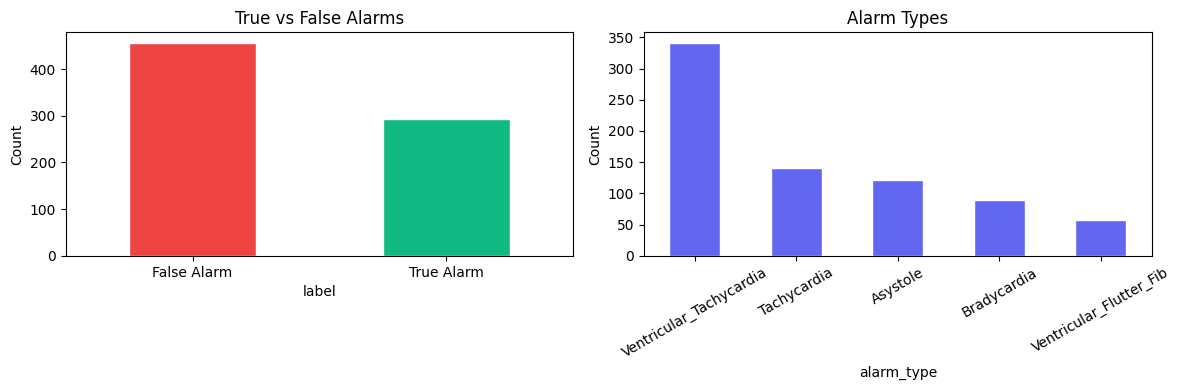

✅ Saved plot → ../results/01_class_balance.png


In [4]:
# ── Cell 3: Class balance ─────────────────────────────────────────────────────
print('=' * 40)
print('CLASS BALANCE')
print('=' * 40)

label_counts = df_records['label'].value_counts()
true_count  = (df_records['label'] == 1).sum()
false_count = (df_records['label'] == 0).sum()
print(f"True alarms  (1): {true_count}")
print(f"False alarms (0): {false_count}")
print(f"Imbalance ratio : {false_count/true_count:.2f}x more false alarms")
print(f"\nAlarm type counts:")
print(df_records['alarm_type'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_records['label'].map({1:'True Alarm', 0:'False Alarm'}) \
    .value_counts().plot(kind='bar', ax=axes[0],
                         color=['#EF4444','#10B981'], edgecolor='white')
axes[0].set_title('True vs False Alarms')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df_records['alarm_type'].value_counts().plot(kind='bar', ax=axes[1],
                                              color='#6366F1', edgecolor='white')
axes[1].set_title('Alarm Types')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f'{PATH_RESULTS}/01_class_balance.png', dpi=150)
plt.show()
print(f"✅ Saved plot → {PATH_RESULTS}/01_class_balance.png")

In [5]:
# ── Cell 4: Signal quality audit ─────────────────────────────────────────────
print('=' * 40)
print('SIGNAL QUALITY AUDIT')
print('=' * 40)

nan_records = df_records[df_records['has_nan'] == True]
print(f"\nRecords with NaN values : {len(nan_records)}")
if len(nan_records) > 0:
    print(f"Average NaN %           : {nan_records['nan_pct'].mean():.2f}%")
    print(f"Max NaN %               : {nan_records['nan_pct'].max():.2f}%")
    print("→ These will be interpolated, not dropped")

print(f"\nDuration stats (seconds):")
print(df_records['duration_s'].describe().round(2))

wrong_duration = df_records[df_records['duration_s'] < 250]
print(f"\nRecords shorter than 250s : {len(wrong_duration)}")

print(f"\nChannel count distribution:")
print(df_records['n_channels'].value_counts())
print("  3 channels = ECG x2 + PLETH")
print("  4 channels = ECG x2 + PLETH + ABP")

flat_signals = df_records[df_records['ecg_std'] < 0.001]
print(f"\nFlat/dead signal records : {len(flat_signals)}")
if len(flat_signals) > 0:
    print(flat_signals[['record_id','label','alarm_type','ecg_std']])

SIGNAL QUALITY AUDIT

Records with NaN values : 112
Average NaN %           : 9.48%
Max NaN %               : 60.18%
→ These will be interpolated, not dropped

Duration stats (seconds):
count    750.00
mean     315.00
std       15.01
min      300.00
25%      300.00
50%      315.00
75%      330.00
max      330.00
Name: duration_s, dtype: float64

Records shorter than 250s : 0

Channel count distribution:
n_channels
4    498
3    252
Name: count, dtype: int64
  3 channels = ECG x2 + PLETH
  4 channels = ECG x2 + PLETH + ABP

Flat/dead signal records : 2
    record_id  label               alarm_type  ecg_std
52      v774s      0  Ventricular_Tachycardia      0.0
393     a608s      0                 Asystole      0.0


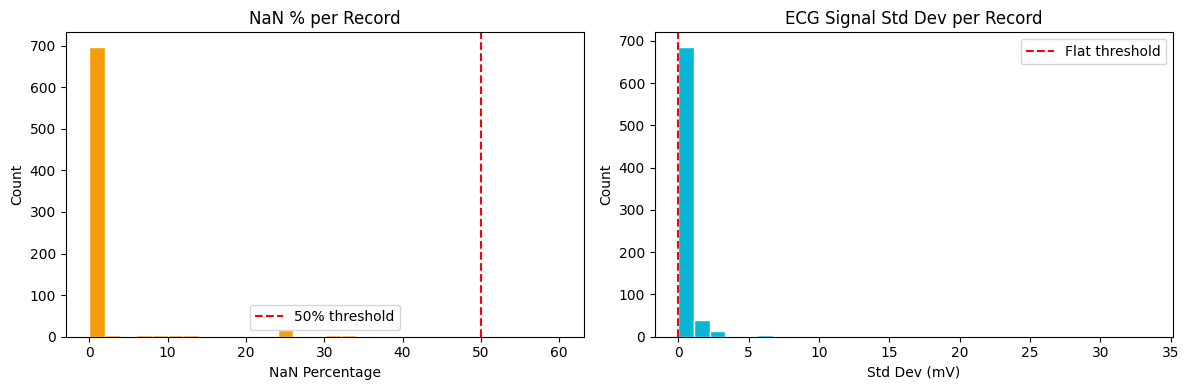

In [6]:
# ── Cell 5: NaN distribution plot ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_records['nan_pct'], bins=30, color='#F59E0B', edgecolor='white')
axes[0].set_title('NaN % per Record')
axes[0].set_xlabel('NaN Percentage')
axes[0].set_ylabel('Count')
axes[0].axvline(x=50, color='red', linestyle='--', label='50% threshold')
axes[0].legend()

axes[1].hist(df_records['ecg_std'], bins=30, color='#06B6D4', edgecolor='white')
axes[1].set_title('ECG Signal Std Dev per Record')
axes[1].set_xlabel('Std Dev (mV)')
axes[1].set_ylabel('Count')
axes[1].axvline(x=0.001, color='red', linestyle='--', label='Flat threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{PATH_RESULTS}/02_signal_quality.png', dpi=150)
plt.show()

In [7]:
# ── Cell 6: Clean + save ──────────────────────────────────────────────────────
print('=' * 40)
print('CLEANING DECISIONS')
print('=' * 40)

original_count = len(df_records)
bad_records    = set()

# Rule 1: Flat ECG (sensor disconnect)
bad_records.update(df_records[df_records['ecg_std'] < 0.001]['record_id'])

# Rule 2: Too short
bad_records.update(df_records[df_records['duration_s'] < 200]['record_id'])

# Rule 3: Missing label
bad_records.update(df_records[df_records['label'] == -1]['record_id'])

print(f"Records flagged for removal : {len(bad_records)}")
print(f"  Flat signals   : {len(df_records[df_records['ecg_std'] < 0.001])}")
print(f"  Too short      : {len(df_records[df_records['duration_s'] < 200])}")
print(f"  Missing labels : {len(df_records[df_records['label'] == -1])}")

df_clean = df_records[~df_records['record_id'].isin(bad_records)].reset_index(drop=True)

print(f"\nBefore cleaning : {original_count}")
print(f"After  cleaning : {len(df_clean)}")
print(f"Removed         : {original_count - len(df_clean)}")

# Save to Data folder (not results — this is input for next step)
save_path = f'{PATH_2015}/clean_records.csv'
df_clean.to_csv(save_path, index=False)
print(f"\n✅ Saved: {os.path.abspath(save_path)}")

CLEANING DECISIONS
Records flagged for removal : 2
  Flat signals   : 2
  Too short      : 0
  Missing labels : 0

Before cleaning : 750
After  cleaning : 748
Removed         : 2

✅ Saved: /Users/adityasitapara/PycharmProjects/ECG_Fatigue/Backend/Data/physionet2015/clean_records.csv


In [8]:
path_mitbih = '../Data/mitbih'

csv_files = sorted([
    f for f in os.listdir(path_mitbih)
    if f.endswith('.csv')
])

rec_ids = sorted(
    set(f.replace('.csv', '') for f in csv_files)
)

print(f"MIT-BIH records found: {len(rec_ids)}")

mitbih_info = []

for rec_id in rec_ids:
    try:

        df_sig = pd.read_csv(
            os.path.join(path_mitbih, f'{rec_id}.csv')
        )

        # Convert all columns to numeric
        for col in df_sig.columns:
            df_sig[col] = pd.to_numeric(
                df_sig[col],
                errors='coerce'
            )

        # Remove completely empty columns
        df_sig = df_sig.dropna(axis=1, how='all')

        # Remove sample number column
        if df_sig.shape[1] >= 3:
            signal_df = df_sig.iloc[:, 1:]
        else:
            signal_df = df_sig

        nan_count = signal_df.isna().sum().sum()

        n_samples = len(signal_df)
        n_channels = signal_df.shape[1]

        ecg_std = signal_df.iloc[:, 0].std()
        ecg_min = signal_df.iloc[:, 0].min()
        ecg_max = signal_df.iloc[:, 0].max()

        mitbih_info.append({
            'record_id': rec_id,
            'n_samples': n_samples,
            'n_channels': n_channels,
            'nan_count': nan_count,
            'ecg_std': ecg_std,
            'ecg_min': ecg_min,
            'ecg_max': ecg_max
        })

    except Exception as e:
        print(f"⚠️ {rec_id}: {e}")

df_mitbih = pd.DataFrame(mitbih_info)

print(df_mitbih.shape)
display(df_mitbih.head())

print("\nSummary:")
print(df_mitbih.describe())

MIT-BIH records found: 50
(50, 7)


,record_id,n_samples,n_channels,nan_count,ecg_std,ecg_min,ecg_max
0,100,650000,2,0,38.639938,481.0,1311.0
1,101,650000,2,0,52.231329,389.0,1508.0
2,102,650000,2,0,38.097843,692.0,1299.0
3,103,650000,2,0,64.368110,502.0,1649.0
4,104,650000,2,0,50.076360,637.0,1419.0



Summary:
           n_samples  n_channels  nan_count     ecg_std     ecg_min  \
count      50.000000   50.000000       50.0   50.000000   50.000000   
mean   626188.880000    9.400000        0.0   69.788490  477.620000   
std    118021.017837   36.620503        0.0   32.316078  203.901926   
min     21891.000000    2.000000        0.0    0.218664    0.000000   
25%    650000.000000    2.000000        0.0   51.612355  386.000000   
50%    650000.000000    2.000000        0.0   65.314214  479.500000   
75%    650000.000000    2.000000        0.0   84.835774  608.000000   
max    650000.000000  187.000000        0.0  171.606799  800.000000   

          ecg_max  
count    50.00000  
mean   1449.24000  
std     338.52185  
min       1.00000  
25%    1402.50000  
50%    1507.00000  
75%    1600.50000  
max    2047.00000  


In [9]:
# ==========================================
# CELL 7 — CHECK MIT-BIH ANNOTATIONS
# ==========================================

all_beat_types = []

for rec_id in rec_ids:

    ann_path = os.path.join(
        path_mitbih,
        f"{rec_id}annotations.txt"
    )

    if not os.path.exists(ann_path):
        print(f"⚠️ Missing annotation file: {rec_id}")
        continue

    try:

        ann = pd.read_csv(
            ann_path,
            sep=r"\s+",
            skiprows=1,          # Skip header line
            header=None,
            engine="python",
            on_bad_lines="skip"  # Handles malformed rows like record 106
        )

        # Column 2 contains beat type
        beat_types = ann.iloc[:, 2].astype(str)

        all_beat_types.extend(
            beat_types.dropna().tolist()
        )

    except Exception as e:
        print(f"⚠️ {rec_id}: {e}")

# ==========================================
# BUILD DISTRIBUTION
# ==========================================

beat_series = pd.Series(all_beat_types)

print("=" * 40)
print("BEAT TYPE DISTRIBUTION")
print("=" * 40)

print(beat_series.value_counts())

# ==========================================
# NORMAL VS ARRHYTHMIA
# ==========================================

normal_count = (beat_series == 'N').sum()
arrhythmia_count = (beat_series != 'N').sum()

print(f"\nNormal beats     : {normal_count:,}")
print(f"Arrhythmia beats : {arrhythmia_count:,}")

total_beats = normal_count + arrhythmia_count

if total_beats > 0:
    print(
        f"Arrhythmia ratio : "
        f"{100 * arrhythmia_count / total_beats:.2f}%"
    )

# ==========================================
# SAVE DISTRIBUTION
# ==========================================

beat_distribution = beat_series.value_counts().reset_index()
beat_distribution.columns = ['beat_type', 'count']

beat_distribution.to_csv(
    '../results/mitbih_beat_distribution.csv',
    index=False
)

print(
    "\n✅ Saved beat distribution to "
    "../results/mitbih_beat_distribution.csv"
)

⚠️ Missing annotation file: mitbih_test
⚠️ Missing annotation file: mitbih_train
BEAT TYPE DISTRIBUTION
N    75052
L     8075
R     7259
V     7130
/     7028
A     2546
+     1250
f      982
F      803
~      616
!      472
"      437
j      229
x      193
a      150
|      132
E      106
J       83
Q       33
e       16
[        6
]        6
S        2
Name: count, dtype: int64

Normal beats     : 75,052
Arrhythmia beats : 37,554
Arrhythmia ratio : 33.35%

✅ Saved beat distribution to ../results/mitbih_beat_distribution.csv


In [10]:
# ==========================================
# CELL 8 — MIMIC-III FULL AUDIT
# ==========================================

path_mimic = '../Data/MimicDemo'

files = {
    'PATIENTS': 'PATIENTS.csv',
    'ICUSTAYS': 'ICUSTAYS.csv',
    'ADMISSIONS': 'ADMISSIONS.csv',
    'CHARTEVENTS': 'CHARTEVENTS.csv',
    'LABEVENTS': 'LABEVENTS.csv',
    'DIAGNOSES_ICD': 'DIAGNOSES_ICD.csv',
    'PRESCRIPTIONS': 'PRESCRIPTIONS.csv',
    'D_ITEMS': 'D_ITEMS.csv'
}

dataframes = {}

print("=" * 50)
print(f"{'Table':<20} {'Rows':>10} {'Cols':>8} {'Missing%':>12}")
print("=" * 50)

for name, fname in files.items():

    full_path = os.path.join(path_mimic, fname)

    if not os.path.exists(full_path):
        print(f"⚠️ Missing file: {fname}")
        continue

    df = pd.read_csv(
        full_path,
        low_memory=False
    )

    dataframes[name] = df

    missing_pct = (
        df.isna()
          .mean()
          .mean()
          * 100
    )

    print(
        f"{name:<20}"
        f"{len(df):>10,}"
        f"{df.shape[1]:>8}"
        f"{missing_pct:>11.1f}%"
    )

Table                      Rows     Cols     Missing%
PATIENTS                   100       8        6.6%
ICUSTAYS                   136      12        0.0%
ADMISSIONS                 129      19        9.3%
CHARTEVENTS            758,355      15       25.1%
LABEVENTS               76,074       9       11.5%
DIAGNOSES_ICD            1,761       5        0.0%
PRESCRIPTIONS           10,398      19        7.0%
D_ITEMS                 12,487      10       39.7%


In [11]:
for name, df in dataframes.items():

    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)

    if len(missing) > 0:

        print(f"\n{'='*40}")
        print(f"{name} — Columns with missing values:")
        print(f"{'='*40}")

        for col, cnt in missing.items():

            pct = cnt / len(df) * 100

            if pct > 80:
                flag = "⚠️ DROP"
            elif pct > 20:
                flag = "🔧 FILL"
            else:
                flag = "✅ OK"

            print(
                f"{col:<35}"
                f"{cnt:>8,}"
                f" ({pct:>5.1f}%) "
                f"{flag}"
            )


PATIENTS — Columns with missing values:
dod_hosp                                 30 ( 30.0%) 🔧 FILL
dod_ssn                                  23 ( 23.0%) 🔧 FILL

ADMISSIONS — Columns with missing values:
deathtime                                89 ( 69.0%) 🔧 FILL
language                                 48 ( 37.2%) 🔧 FILL
edouttime                                37 ( 28.7%) 🔧 FILL
edregtime                                37 ( 28.7%) 🔧 FILL
marital_status                           16 ( 12.4%) ✅ OK
religion                                  1 (  0.8%) ✅ OK

CHARTEVENTS — Columns with missing values:
resultstatus                        736,681 ( 97.1%) ⚠️ DROP
valueuom                            518,500 ( 68.4%) 🔧 FILL
valuenum                            434,471 ( 57.3%) 🔧 FILL
stopped                             383,706 ( 50.6%) 🔧 FILL
error                               376,076 ( 49.6%) 🔧 FILL
warning                             376,076 ( 49.6%) 🔧 FILL
value                              

In [12]:
for name, df in dataframes.items():

    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)

    if len(missing) > 0:

        print(f"\n{'='*40}")
        print(f"{name} — Columns with missing values:")
        print(f"{'='*40}")

        for col, cnt in missing.items():

            pct = cnt / len(df) * 100

            if pct > 80:
                flag = "⚠️ DROP"
            elif pct > 20:
                flag = "🔧 FILL"
            else:
                flag = "✅ OK"

            print(
                f"{col:<35}"
                f"{cnt:>8,}"
                f" ({pct:>5.1f}%) "
                f"{flag}"
            )


PATIENTS — Columns with missing values:
dod_hosp                                 30 ( 30.0%) 🔧 FILL
dod_ssn                                  23 ( 23.0%) 🔧 FILL

ADMISSIONS — Columns with missing values:
deathtime                                89 ( 69.0%) 🔧 FILL
language                                 48 ( 37.2%) 🔧 FILL
edouttime                                37 ( 28.7%) 🔧 FILL
edregtime                                37 ( 28.7%) 🔧 FILL
marital_status                           16 ( 12.4%) ✅ OK
religion                                  1 (  0.8%) ✅ OK

CHARTEVENTS — Columns with missing values:
resultstatus                        736,681 ( 97.1%) ⚠️ DROP
valueuom                            518,500 ( 68.4%) 🔧 FILL
valuenum                            434,471 ( 57.3%) 🔧 FILL
stopped                             383,706 ( 50.6%) 🔧 FILL
error                               376,076 ( 49.6%) 🔧 FILL
warning                             376,076 ( 49.6%) 🔧 FILL
value                              

In [13]:
# ==========================================
# CELL 10 — ICUSTAYS TABLE
# ==========================================

icu = dataframes['ICUSTAYS']

print("=" * 40)
print("ICUSTAYS TABLE")
print("=" * 40)

icu['intime'] = pd.to_datetime(
    icu['intime'],
    errors='coerce'
)

icu['outtime'] = pd.to_datetime(
    icu['outtime'],
    errors='coerce'
)

# Calculate LOS in hours
icu['los_calc'] = (
    icu['outtime']
    - icu['intime']
).dt.total_seconds() / 3600

print(f"Unique patients : {icu['subject_id'].nunique()}")
print(f"Total ICU stays : {len(icu)}")

print("\nICU care units:")
print(
    icu['first_careunit']
    .value_counts()
)

bad_stays = icu[
    icu['los_calc'] <= 0
]

print(
    f"\n⚠️ Stays with zero/negative duration: "
    f"{len(bad_stays)}"
)

print("\nICU length of stay (hours):")
print(
    icu['los_calc']
    .describe()
    .round(2)
)

# Compare with official LOS column
print("\nOfficial LOS column:")
print(
    icu['los']
    .describe()
    .round(2)
)

ICUSTAYS TABLE
Unique patients : 100
Total ICU stays : 136

ICU care units:
first_careunit
MICU     77
SICU     23
CCU      19
TSICU    11
CSRU      6
Name: count, dtype: int64

⚠️ Stays with zero/negative duration: 0

ICU length of stay (hours):
count    136.00
mean     106.86
std      148.72
min        2.54
25%       29.60
50%       50.67
75%      103.90
max      849.76
Name: los_calc, dtype: float64

Official LOS column:
count    136.00
mean       4.45
std        6.20
min        0.11
25%        1.23
50%        2.11
75%        4.33
max       35.41
Name: los, dtype: float64


In [14]:
# ==========================================
# CELL 11 — PATIENTS TABLE
# ==========================================

patients = dataframes['PATIENTS']

print("=" * 40)
print("PATIENTS TABLE")
print("=" * 40)

print(patients.dtypes)
print()

patients['dob'] = pd.to_datetime(
    patients['dob'],
    errors='coerce'
)

patients['dod'] = pd.to_datetime(
    patients['dod'],
    errors='coerce'
)

print("Gender distribution:")
print(patients['gender'].value_counts())

dupes = patients.duplicated(
    subset='subject_id'
).sum()

print(f"\nDuplicate patient IDs: {dupes}")

PATIENTS TABLE
row_id         int64
subject_id     int64
gender           str
dob              str
dod              str
dod_hosp         str
dod_ssn          str
expire_flag    int64
dtype: object

Gender distribution:
gender
F    55
M    45
Name: count, dtype: int64

Duplicate patient IDs: 0


In [15]:
charts = dataframes['CHARTEVENTS']
d_items = dataframes['D_ITEMS']

print("=" * 40)
print("CHARTEVENTS TABLE")
print("=" * 40)

charts_named = charts.merge(
    d_items[['itemid', 'label']],
    on='itemid',
    how='left'
)

vital_keywords = [
    'Heart Rate',
    'SpO2',
    'Blood Pressure',
    'Respiratory Rate',
    'Temperature'
]

print("Key vitals available:")

for kw in vital_keywords:

    matches = d_items[
        d_items['label'].str.contains(
            kw,
            na=False,
            case=False
        )
    ]

    count = charts[
        charts['itemid'].isin(
            matches['itemid']
        )
    ].shape[0]

    label_name = (
        matches['label'].iloc[0]
        if len(matches) > 0
        else 'NOT FOUND'
    )

    print(
        f"{kw:<25}: "
        f"{count:>8} measurements | "
        f"{label_name}"
    )

print("\nCHARTEVENTS VALUE column:")
print(f"  Dtype       : {charts['value'].dtype}")
print(f"  Null count  : {charts['value'].isna().sum()}")

print(
    f"  Sample vals : "
    f"{charts['value'].dropna().unique()[:5]}"
)

print("\nCHARTEVENTS VALUENUM column:")
print(charts['valuenum'].describe())

hr_items = d_items[
    d_items['label']
    .str.contains(
        'Heart Rate',
        na=False,
        case=False
    )
]['itemid']

hr_data = (
    charts[
        charts['itemid']
        .isin(hr_items)
    ]['valuenum']
    .dropna()
)

if len(hr_data) > 0:

    print(
        f"\nHeart Rate range: "
        f"{hr_data.min():.0f} – "
        f"{hr_data.max():.0f} bpm"
    )

    outlier_hr = hr_data[
        (hr_data < 20)
        | (hr_data > 300)
    ]

    print(
        f"Outlier HR values "
        f"(<20 or >300 bpm): "
        f"{len(outlier_hr)}"
    )
else:
    print("\n⚠️ No Heart Rate measurements found.")

CHARTEVENTS TABLE
Key vitals available:
Heart Rate               :    17258 measurements | Heart Rate
SpO2                     :    16116 measurements | SpO2
Blood Pressure           :    25682 measurements | Arterial Blood Pressure systolic
Respiratory Rate         :    17580 measurements | Respiratory Rate
Temperature              :    11594 measurements | RLE [Temperature]

CHARTEVENTS VALUE column:
  Dtype       : str
  Null count  : 32848
  Sample vals : <StringArray>
['95.9', '2222221.7', '15', '94', '163']
Length: 5, dtype: str

CHARTEVENTS VALUENUM column:
count    3.238840e+05
mean     8.157890e+01
std      3.911579e+03
min     -5.000000e+02
25%      4.000000e+00
50%      3.500000e+01
75%      9.200000e+01
max      2.222222e+06
Name: valuenum, dtype: float64

Heart Rate range: 0 – 580 bpm
Outlier HR values (<20 or >300 bpm): 20


In [16]:
print("\n" + "=" * 50)
print("DATA CLEANING SUMMARY REPORT")
print("=" * 50)

true_alarms = (df_clean['label'] == 1).sum()
false_alarms = (df_clean['label'] == 0).sum()

print(f"""
PHYSIONET 2015 CHALLENGE:
  Total records        : {len(df_records)}
  Clean records        : {len(df_clean)}
  Records dropped      : {len(df_records) - len(df_clean)}
  True alarms          : {true_alarms}
  False alarms         : {false_alarms}
  Records with NaN     : {df_clean['has_nan'].sum()} (need interpolation)

MIT-BIH DATABASE:
  Records              : {len(df_mitbih)}
  Total beats          : {len(beat_series):,}
  Arrhythmia beats     : {arrhythmia_count:,}

MIMIC-III DEMO:
  Patients             : {len(dataframes['PATIENTS'])}
  ICU stays            : {len(dataframes['ICUSTAYS'])}
  Chart measurements   : {len(dataframes['CHARTEVENTS']):,}
  Lab measurements     : {len(dataframes['LABEVENTS']):,}

ACTIONS NEEDED:
  1. Interpolate NaN values in waveform signals
  2. Handle class imbalance during training
  3. Clip CHARTEVENTS outliers (HR < 20 or > 300)
  4. Remove columns with >80% missing values
""")


DATA CLEANING SUMMARY REPORT

PHYSIONET 2015 CHALLENGE:
  Total records        : 750
  Clean records        : 748
  Records dropped      : 2
  True alarms          : 294
  False alarms         : 454
  Records with NaN     : 110 (need interpolation)

MIT-BIH DATABASE:
  Records              : 50
  Total beats          : 112,606
  Arrhythmia beats     : 37,554

MIMIC-III DEMO:
  Patients             : 100
  ICU stays            : 136
  Chart measurements   : 758,355
  Lab measurements     : 76,074

ACTIONS NEEDED:
  1. Interpolate NaN values in waveform signals
  2. Handle class imbalance during training
  3. Clip CHARTEVENTS outliers (HR < 20 or > 300)
  4. Remove columns with >80% missing values

